# CNPI Hybrid RAG — Graph Notebook

এই notebook-এ `graph.py` থেকে গ্রাফ import করে test করা হয়।

> **Note:** Jupyter Notebook-এ `__file__` নেই, তাই প্রথম cell-এ `sys.path` manually সেট করা হয়।

In [1]:
"""
Graph Builder - Phase 1, 2, 3, 4 & 5 (Complete)
==================================================

This file builds the COMPLETE LangGraph for the CNPI RAG system:
- Phase 1 (Router)         : rewrite_query → llm_decide_path → confidence_score check
- Phase 2 (SQL Query)      : info_check → create → db_call → row_check → response → support_check
- Phase 3 (SQL Retrieve)   : check → create → context → response → support_check
- Phase 4 (Web Search)     : rewrite → docs → response → support_check
- Phase 5 (Hybrid/Sub-Q)   : depth_check → create_sub_questions → dispatch (Send API)
                             → [parallel paths] → append_sub_answer → merge → support → retry_check

Key Phase 5 design (LangGraph Send API map-reduce):
    dispatch_sub_queries returns a list[Send] targeting `rewrite_query`.
    Each Send carries an isolated sub-state with is_sub_query_call=True.
    When a path support_check finishes, is_sub_query_call=True routes to
    append_sub_answer instead of END.
    append_sub_answer uses hybrid.sub_query_ans (operator.add reducer) to
    fan-in all parallel results, then routes to merge_sub_answers when
    sub_ans_count == total_sub_q.
"""

import sys
from pathlib import Path
from typing import Literal

# Ensure plan/ is on the path so that `from state import RAGState` works
# Note: __file__ is not defined in Jupyter notebooks, so we use a fallback.
try:
    _project_root = Path(__file__).resolve().parent
except NameError:
    # Running inside a Jupyter / IPython kernel — use the notebook's CWD
    import os
    _project_root = Path(os.getcwd()).resolve()

_plan_root = _project_root.parent / "plan"
for _p in [str(_plan_root), str(_project_root)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from langgraph.graph import StateGraph, END

# Import state from canonical source
from state import RAGState, MAX_RETRIES, MAX_HYBRID_DEPTH

# Import Phase 1 nodes
from nodes.entity_normalizer import entity_normalizer_node
from nodes.entry import rewrite_query_node
from nodes.router import llm_decide_path_node

# Import Evidence Verification node (NEW - inserted before response generation)
from nodes.evidence_verification import evidence_verification_node

# Import Phase 2 nodes (SQL Query path)
from nodes.sql_query_create import sql_query_create_node
from nodes.sql_query_db_call import sql_query_db_call_node
from nodes.context_format import context_format_node
from nodes.fallback_dispatcher import fallback_dispatcher_node

# ★ Wrapper: context_retrieve = sql_query_create + sql_query_db_call (generates SQL + executes + returns contexts)
def context_retrieve_node(state: RAGState) -> dict:
    """
    Convenience wrapper that combines SQL generation and execution.
    Used for notice queries that bypass info_check.
    
    Flow: sql_query_create (generate SQL) → sql_query_db_call (execute SQL)
    """
    # Step 1: Generate SQL query
    state = {**state, **sql_query_create_node(state)}
    
    # Step 2: Execute the SQL query
    state = {**state, **sql_query_db_call_node(state)}
    
    return {"sql_query": state.get("sql_query", {})}

# Import Phase 3 nodes (SQL Retrieve path)
from nodes.sql_retrieve_check import sql_retrieve_check_node
from nodes.sql_retrieve_create import sql_retrieve_create_node
from nodes.sql_retrieve_context import sql_retrieve_context_node
from nodes.sql_retrieve_response import sql_retrieve_response_node
from nodes.sql_retrieve_support_check import sql_retrieve_support_check_node
from nodes.no_answer_found import no_answer_found_node

# Import Phase 4 nodes (Web Search path)
from nodes.web_search_rewrite import web_search_rewrite_node
from nodes.web_search_docs import web_search_docs_node
from nodes.web_search_response import web_search_response_node
from nodes.web_search_support_check import web_search_support_check_node

# Import Phase 5 nodes (Hybrid Sub-Query path)
from nodes.hybrid_depth_check import hybrid_depth_check_node
from nodes.hybrid_create_sub_questions import create_sub_questions_node
from nodes.hybrid_dispatch_sub_queries import dispatch_sub_queries_node
from nodes.hybrid_append_sub_answer import append_sub_answer_node
from nodes.hybrid_merge_sub_answers import merge_sub_answers_node
from nodes.hybrid_merge_support_check import merge_support_check_node
from nodes.hybrid_merge_retry_check import merge_retry_check_node


def process_sub_query_wrapper_node(state: RAGState) -> dict:
    """
    Wrapper node that executes the full pipeline for a single sub-query synchronously.
    This prevents LangGraph from merging states of parallel Send branches across multiple nodes.
    """
    # 1. Phase 1: Rewrite & Normalize
    state = {**state, **rewrite_query_node(state)}
    state = {**state, **entity_normalizer_node(state)}
    
    # 2. Phase 1: Decide Path
    state = {**state, **llm_decide_path_node(state)}
    decided_path = state.get("decided_path")
    
    # 3. Phase 2-4: Execute chosen path
    if decided_path == "sql_query":
        # ★ Bypass info_check, go directly to context_retrieve
        state = {**state, **context_retrieve_node(state)}
        state = {**state, **context_format_node(state)}
            
    elif decided_path == "sql_retrieve":
        state = {**state, **sql_retrieve_check_node(state)}
        if not state.get("sql_retrieve", {}).get("need_more_info"):
            state = {**state, **sql_retrieve_create_node(state)}
            state = {**state, **sql_retrieve_context_node(state)}
            
    elif decided_path == "web_search":
        state = {**state, **web_search_rewrite_node(state)}
        state = {**state, **web_search_docs_node(state)}
        
    # 4. Phase 5: Append answer (returns ONLY the hybrid channel update)
    return append_sub_answer_node(state)


def sub_query_router_node(state: RAGState) -> dict:
    """Pass-through node to make the sub-query exit routing visible in the graph."""
    return state


# =============================================================================
# Graph Builder
# =============================================================================

def build_graph():
    """
    Build the COMPLETE graph for the CNPI RAG system (Phase 1–5).

    Phase 5 (Hybrid) uses LangGraph Send API for parallel sub-query execution:
        dispatch_sub_queries → [Send("rewrite_query", sub_state) × N]
        → each branch traverses its own path (SQL Query / SQL Retrieve / Web Search)
        → converges at append_sub_answer (fan-in via operator.add reducer)
        → merge_sub_answers → merge_support_check → merge_retry_check → END

    Depth guard:
        hybrid_depth_check confirms depth < MAX_HYBRID_DEPTH before decomposing.
        Sub-queries are never allowed to spawn further Hybrid paths.
    """
    graph = StateGraph(RAGState)

    # -------------------------------------------------------------------------
    # Phase 1 nodes
    # -------------------------------------------------------------------------
    graph.add_node("entity_normalizer", entity_normalizer_node)
    graph.add_node("rewrite_query", rewrite_query_node)
    graph.add_node("llm_decide_path", llm_decide_path_node)
    
    # -------------------------------------------------------------------------
    # Evidence Verification node (NEW - sits between context and response)
    # -------------------------------------------------------------------------
    graph.add_node("evidence_verification", evidence_verification_node)

    # -------------------------------------------------------------------------
    # Phase 2 — SQL Query path nodes (HYBRID: Notice queries bypass, others check)
    # -------------------------------------------------------------------------
    # For notice queries: context_retrieve (direct SQL)
    # For other queries: sql_query_info_check → short_info_response or context_retrieve
    from nodes.sql_query_info_check import sql_query_info_check_node
    from nodes.sql_query_short_info_response import sql_query_short_info_response_node
    
    graph.add_node("sql_query_info_check", sql_query_info_check_node)
    graph.add_node("sql_query_short_info_response", sql_query_short_info_response_node)
    graph.add_node("context_retrieve", context_retrieve_node)
    graph.add_node("context_format", context_format_node)
    graph.add_node("fallback_dispatcher", fallback_dispatcher_node)

    # -------------------------------------------------------------------------
    # Phase 3 — SQL Retrieve path nodes
    # -------------------------------------------------------------------------
    graph.add_node("sql_retrieve_check", sql_retrieve_check_node)
    graph.add_node("sql_retrieve_create", sql_retrieve_create_node)
    graph.add_node("sql_retrieve_context", sql_retrieve_context_node)
    graph.add_node("sql_retrieve_response", sql_retrieve_response_node)
    graph.add_node("sql_retrieve_support_check", sql_retrieve_support_check_node)

    # -------------------------------------------------------------------------
    # Phase 4 — Web Search path nodes
    # -------------------------------------------------------------------------
    graph.add_node("web_search_rewrite", web_search_rewrite_node)
    graph.add_node("web_search_docs", web_search_docs_node)
    graph.add_node("web_search_response", web_search_response_node)
    graph.add_node("web_search_support_check", web_search_support_check_node)
    graph.add_node("no_answer_found", no_answer_found_node)

    # -------------------------------------------------------------------------
    # Phase 5 — Hybrid Sub-Query path nodes
    # -------------------------------------------------------------------------
    graph.add_node("hybrid_depth_check", hybrid_depth_check_node)
    graph.add_node("create_sub_questions", create_sub_questions_node)
    # dispatch_sub_queries is a conditional edge, not a node.
    graph.add_node("sub_query_router_node", sub_query_router_node)
    graph.add_node("process_sub_query_wrapper", process_sub_query_wrapper_node)
    graph.add_node("append_sub_answer", append_sub_answer_node)
    graph.add_node("merge_sub_answers", merge_sub_answers_node)
    graph.add_node("merge_support_check", merge_support_check_node)
    graph.add_node("merge_retry_check", merge_retry_check_node)

    # -------------------------------------------------------------------------
    # Phase 1 edges
    # -------------------------------------------------------------------------
    graph.add_edge("rewrite_query", "entity_normalizer")
    graph.add_edge("entity_normalizer", "llm_decide_path")

    # ---- Router: decide path and check if notice query ----
    def _route_after_decision(state: RAGState) -> Literal[
        "llm_decide_path",
        "sql_query_info_check",
        "context_retrieve",
        "sql_retrieve_check",
        "sql_retrieve_response",
        "web_search_rewrite",
        "hybrid_depth_check",
        "__end__",
    ]:
        """Route to the right path entry node based on confidence + decided_path.
        
        For sql_query path:
        - If it's a NOTICE query (latest/last N) → context_retrieve (bypass info_check)
        - Otherwise → sql_query_info_check (validate info first)
        
        For no_path:
        - Route directly to sql_retrieve_response (bypass all retrieval steps)
        """
        confidence_score = state.get("confidence_score", 0.0)
        if confidence_score < 0.7:
            return "hybrid_depth_check"

        decided_path = state.get("decided_path", "sql_retrieve")
        
        # ★ NEW: Handle no_path by routing directly to sql_retrieve_response
        if decided_path == "no_path":
            return "sql_retrieve_response"
        
        if decided_path == "sql_query":
            # ★ Check if it's a notice query
            query = state.get("normalized_query", "") or state.get("user_input", "")
            query_lower = query.lower()
            
            # Notice query keywords
            notice_keywords = [
                "latest notice", "last notice", "সর্বশেষ নোটিশ", "শেষ নোটিশ",
                "last 5 notice", "last 3 notice", "last 10 notice",
                "শেষ ৫টি", "শেষ ৩টি", "শেষ ১০টি",
                "সর্বশেষ ৫টি", "সর্বশেষ ৩টি"
            ]
            
            is_notice_query = any(keyword in query_lower for keyword in notice_keywords)
            
            if is_notice_query:
                return "context_retrieve"  # ★ Bypass info_check for notice queries
            else:
                return "sql_query_info_check"  # ★ Check info for other queries
                
        elif decided_path == "sql_retrieve":
            return "sql_retrieve_check"
        elif decided_path == "web_search":
            return "web_search_rewrite"
        elif decided_path == "hybrid":
            return "hybrid_depth_check"
        else:
            return "__end__"

    graph.add_conditional_edges(
        "llm_decide_path",
        _route_after_decision,
        {
            "llm_decide_path": "llm_decide_path",
            "sql_query_info_check": "sql_query_info_check",
            "context_retrieve": "context_retrieve",
            "sql_retrieve_check": "sql_retrieve_check",
            "sql_retrieve_response": "sql_retrieve_response",
            "web_search_rewrite": "web_search_rewrite",
            "hybrid_depth_check": "hybrid_depth_check",
            "__end__": END,
        },
    )

    # -------------------------------------------------------------------------
    # Phase 2 — SQL Query path edges
    # -------------------------------------------------------------------------
    
    # info_check → (short_info? short_info_response : context_retrieve)
    def _route_after_info_check(state: RAGState) -> Literal[
        "sql_query_short_info_response", "context_retrieve"
    ]:
        """Check if query has sufficient info."""
        sql_query_state = state.get("sql_query", {})
        short_info = sql_query_state.get("short_info", False)
        not_possible = sql_query_state.get("not_possible", False)
        
        if short_info or not_possible:
            return "sql_query_short_info_response"
        return "context_retrieve"
    
    graph.add_conditional_edges(
        "sql_query_info_check",
        _route_after_info_check,
        {
            "sql_query_short_info_response": "sql_query_short_info_response",
            "context_retrieve": "context_retrieve",
        },
    )
    
    # short_info_response → END (clarification sent to user)
    graph.add_edge("sql_query_short_info_response", END)
    
    # context_retrieve → context_format → evidence_verification (for sql_query path)
    graph.add_edge("context_retrieve", "context_format")
    
    # After context_format, check if we need verification
    def _route_after_context_format(state: RAGState) -> Literal["evidence_verification", "sql_retrieve_response"]:
        """Route to evidence verification if we have context."""
        sql_query_state = state.get("sql_query", {})
        context = sql_query_state.get("optimized_context") or sql_query_state.get("raw_context", "")
        
        if context and context.strip():
            return "evidence_verification"
        return "sql_retrieve_response"
    
    graph.add_conditional_edges(
        "context_format",
        _route_after_context_format,
        {
            "evidence_verification": "evidence_verification",
            "sql_retrieve_response": "sql_retrieve_response"
        }
    )

    # Bridge between fallback dispatcher and real SQL Retrieve
    graph.add_edge("fallback_dispatcher", "sql_retrieve_check")

    # -------------------------------------------------------------------------
    # Phase 3 — SQL Retrieve path edges
    # -------------------------------------------------------------------------

    # check → (need_more_info? short_info_response : create)
    def _route_retrieve_check(state: RAGState) -> Literal[
        "sql_retrieve_create", "sql_query_short_info_response"
    ]:
        """If unsuitable/needs more info, route to short_info_response."""
        sql_retrieve_state = state.get("sql_retrieve", {})
        need_more_info = sql_retrieve_state.get("need_more_info", False)
        return "sql_query_short_info_response" if need_more_info else "sql_retrieve_create"

    graph.add_conditional_edges(
        "sql_retrieve_check",
        _route_retrieve_check,
        {
            "sql_retrieve_create": "sql_retrieve_create",
            "sql_query_short_info_response": "sql_query_short_info_response",
        },
    )

    graph.add_edge("sql_retrieve_create", "sql_retrieve_context")

    # context → evidence_verification → sub_query_router_node
    # Router will handle: sub_query→append, context_found→sql_retrieve_response, no_context→END
    def _route_after_sql_retrieve_context(state: RAGState) -> Literal["evidence_verification", "sub_query_router_node"]:
        """Check if we have context to verify before routing."""
        sql_retrieve_state = state.get("sql_retrieve", {})
        context_found = sql_retrieve_state.get("context_found", False)
        
        # Only verify if we have context
        if context_found:
            return "evidence_verification"
        return "sub_query_router_node"
    
    graph.add_conditional_edges(
        "sql_retrieve_context",
        _route_after_sql_retrieve_context,
        {
            "evidence_verification": "evidence_verification",
            "sub_query_router_node": "sub_query_router_node"
        }
    )

    # ★ NEW: Conditional edge from sql_retrieve_response
    # If skip_support_check=True (no context), go directly to END
    # Otherwise, go to support_check for validation
    def _route_after_retrieve_response(state: RAGState) -> Literal[
        "sql_retrieve_support_check", "__end__"
    ]:
        """Route to support_check or END based on skip_support_check flag.
        
        If skip_support_check=True (set by response node when there's no context),
        skip validation and go directly to END.
        """
        sql_retrieve_state = state.get("sql_retrieve", {})
        skip_support = sql_retrieve_state.get("skip_support_check", False)
        
        if skip_support:
            return "__end__"
        return "sql_retrieve_support_check"
    
    graph.add_conditional_edges(
        "sql_retrieve_response",
        _route_after_retrieve_response,
        {
            "sql_retrieve_support_check": "sql_retrieve_support_check",
            "__end__": END,
        },
    )

    # SQL Retrieve support_check: retry → sql_retrieve_RESPONSE (not create), max MAX_RETRIES
    def _route_retrieve_support_check(state: RAGState) -> Literal[
        "__end__", "sql_retrieve_response", "no_answer_found"
    ]:
        """If support check returns false (answer not good), retry the LLM response node.

        Retries sql_retrieve_response directly (same context, fresh LLM generation).
        Maximum MAX_RETRIES attempts before giving up and going to no_answer_found.
        """
        sql_retrieve_state = state.get("sql_retrieve", {})
        retry_count = sql_retrieve_state.get("retry_count", 0)
        supported = sql_retrieve_state.get("supported", True)   # set by support_check node

        if supported:
            return "__end__"
        
        if retry_count < MAX_RETRIES:
            return "sql_retrieve_response"   # retry LLM with same context

        return "no_answer_found"   # retries exhausted or no_support found

    graph.add_conditional_edges(
        "sql_retrieve_support_check",
        _route_retrieve_support_check,
        {
            "__end__": END,
            "sql_retrieve_response": "sql_retrieve_response",
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # Phase 4 — Web Search path edges
    # -------------------------------------------------------------------------

    # rewrite → docs (always)
    graph.add_edge("web_search_rewrite", "web_search_docs")

    # docs → evidence_verification → sub_query_router_node
    # Router will handle: sub_query→append, context→web_search_response, no_context→END
    def _route_after_web_search_docs(state: RAGState) -> Literal["evidence_verification", "sub_query_router_node"]:
        """Check if we have context to verify before routing."""
        web_search_state = state.get("web_search", {})
        context = web_search_state.get("context", "").strip()
        
        # Only verify if we have context
        if context:
            return "evidence_verification"
        return "sub_query_router_node"
    
    graph.add_conditional_edges(
        "web_search_docs",
        _route_after_web_search_docs,
        {
            "evidence_verification": "evidence_verification",
            "sub_query_router_node": "sub_query_router_node"
        }
    )

    # response → support_check (always)
    graph.add_edge("web_search_response", "web_search_support_check")

    # Web Search support_check: retry logic only — sub_queries never reach here
    def _route_web_support_check(state: RAGState) -> Literal[
        "__end__", "web_search_response", "no_answer_found"
    ]:
        """Retry if answer not found and retries remain; otherwise go to no_answer_found."""
        answer_status = state.get("answer_status", "pending")
        if answer_status == "found":
            return "__end__"

        web_search_state = state.get("web_search", {})
        retry_count = web_search_state.get("retry_count", 0)
        if retry_count < MAX_RETRIES:
            return "web_search_response"

        return "no_answer_found"

    graph.add_conditional_edges(
        "web_search_support_check",
        _route_web_support_check,
        {
            "__end__": END,
            "web_search_response": "web_search_response",
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # No Answer Found Node Edge
    # -------------------------------------------------------------------------
    graph.add_edge("no_answer_found", END)

    # =========================================================================
    # Phase 5 — Hybrid Sub-Query path edges
    # =========================================================================

    # ---- Depth check: depth < MAX_HYBRID_DEPTH → decompose, else → fallback ----
    def _route_after_depth_check(state: RAGState) -> Literal[
        "create_sub_questions", "sql_retrieve_check"
    ]:
        """Allow sub-query decomposition only at depth < MAX_HYBRID_DEPTH.

        depth was INCREMENTED by hybrid_depth_check_node; so after that node:
            depth == 1 (came from 0) → still within limit → decompose
            depth >= 2              → already nested    → fallback to sql_retrieve
        """
        hybrid_state = state.get("hybrid", {})
        depth: int = hybrid_state.get("depth", 1)
        if depth <= MAX_HYBRID_DEPTH:
            return "create_sub_questions"
        # Sub-query recursion guard: fall back to sql_retrieve
        return "sql_retrieve_check"

    graph.add_conditional_edges(
        "hybrid_depth_check",
        _route_after_depth_check,
        {
            "create_sub_questions": "create_sub_questions",
            "sql_retrieve_check": "sql_retrieve_check",
        },
    )

    # dispatch_sub_queries uses Send API — returns list[Send("rewrite_query", sub_state)]
    # LangGraph handles the fan-out automatically; each branch re-enters the full pipeline.
    # In LangGraph, nodes returning List[Send] must be used as conditional edges!
    graph.add_conditional_edges("create_sub_questions", dispatch_sub_queries_node)
    
    # Wrapper node directly returns the appended answer, so we route it to merge
    graph.add_edge("process_sub_query_wrapper", "merge_sub_answers")

    # After verification, route based on decided_path
    def _route_after_verification(state: RAGState) -> Literal["sql_retrieve_response", "sub_query_router_node"]:
        """After evidence verification, route to appropriate response node or router."""
        decided_path = state.get("decided_path", "sql_retrieve")
        
        # For sql_query path, go directly to sql_retrieve_response (which handles sql_query too)
        if decided_path == "sql_query":
            return "sql_retrieve_response"
        
        # For sql_retrieve and web_search, go to sub_query_router_node
        return "sub_query_router_node"
    
    graph.add_conditional_edges(
        "evidence_verification",
        _route_after_verification,
        {
            "sql_retrieve_response": "sql_retrieve_response",
            "sub_query_router_node": "sub_query_router_node"
        }
    )
    
    # ---- Central gateway: decides for ALL paths after context is collected ----
    def _route_sub_query_node(state: RAGState) -> Literal[
        "append_sub_answer",
        "sql_retrieve_response",
        "web_search_response",
        "fallback_dispatcher",
        "no_answer_found",
        "__end__",
    ]:
        """Single decision point between context collection and response generation.

        Sub-query branch (is_sub_query_call=True):
            -> append_sub_answer  (always -- context collected, skip LLM)

        Normal branch (is_sub_query_call=False), routed by decided_path:
            sql_query  : final_answer is already computed, just end
            sql_retrieve: context_found -> sql_retrieve_response
                           no context   -> no_answer_found
            web_search : context found -> web_search_response
                         no context   -> no_answer_found
        """
        is_sub_query_call = state.get("is_sub_query_call", False)

        # Sub-query branches: collect context, skip LLM, fan-in
        if is_sub_query_call:
            return "append_sub_answer"

        # If clarification was already generated (need_more_info / not_found),
        # the final_answer is already set — go straight to END.
        answer_status = state.get("answer_status", "pending")
        if answer_status in ("need_more_info", "not_found"):
            return "__end__"

        # Normal query: route to the correct response LLM node
        decided_path = state.get("decided_path", "sql_retrieve")

        if decided_path == "sql_query":
            # the answer is already generated by final_answer node and stored in final_answer
            return "__end__"

        elif decided_path == "sql_retrieve":
            context_found = state.get("sql_retrieve", {}).get("context_found", False)
            return "sql_retrieve_response" if context_found else "no_answer_found"

        elif decided_path == "web_search":
            context = state.get("web_search", {}).get("context", "").strip()
            return "web_search_response" if context else "no_answer_found"

        return "no_answer_found"

    graph.add_conditional_edges(
        "sub_query_router_node",
        _route_sub_query_node,
        {
            "append_sub_answer": "append_sub_answer",
            "sql_retrieve_response": "sql_retrieve_response",
            "web_search_response": "web_search_response",
            "fallback_dispatcher": "fallback_dispatcher",
            "no_answer_found": "no_answer_found",
            "__end__": END,
        }
    )

    # append_sub_answer → merge_sub_answers
    # LangGraph AUTOMATICALLY waits for all parallel branches to accumulate their
    # outputs into the 'sub_query_ans' list reducer before moving on to merge.
    # We do NOT need a manual while loop here!
    graph.add_edge("append_sub_answer", "merge_sub_answers")

    # merge_sub_answers → merge_support_check (always)
    graph.add_edge("merge_sub_answers", "merge_support_check")

    # merge_support_check → merge_retry_check (always)
    graph.add_edge("merge_support_check", "merge_retry_check")

    # merge_retry_check: found → END | retry → merge_sub_answers | exhausted → no_answer_found
    def _route_merge_retry_check(state: RAGState) -> Literal[
        "merge_sub_answers", "__end__", "no_answer_found"
    ]:
        """Retry merge if not yet supported and retries remain."""
        hybrid_state = state.get("hybrid", {})
        merge_retries: int = hybrid_state.get("merge_retries", 0)
        answer_status: str = state.get("answer_status", "not_found")

        if answer_status == "found":
            return "__end__"            # final answer accepted
        if merge_retries < MAX_RETRIES:
            return "merge_sub_answers"  # retry the LLM merge
        return "no_answer_found"                # exhausted

    graph.add_conditional_edges(
        "merge_retry_check",
        _route_merge_retry_check,
        {
            "merge_sub_answers": "merge_sub_answers",
            "__end__": END,
            "no_answer_found": "no_answer_found",
        },
    )

    # -------------------------------------------------------------------------
    # Entry point
    # -------------------------------------------------------------------------
    graph.set_entry_point("rewrite_query")

    return graph


# Build and export the final app
app = build_graph()


g:\Genarative-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


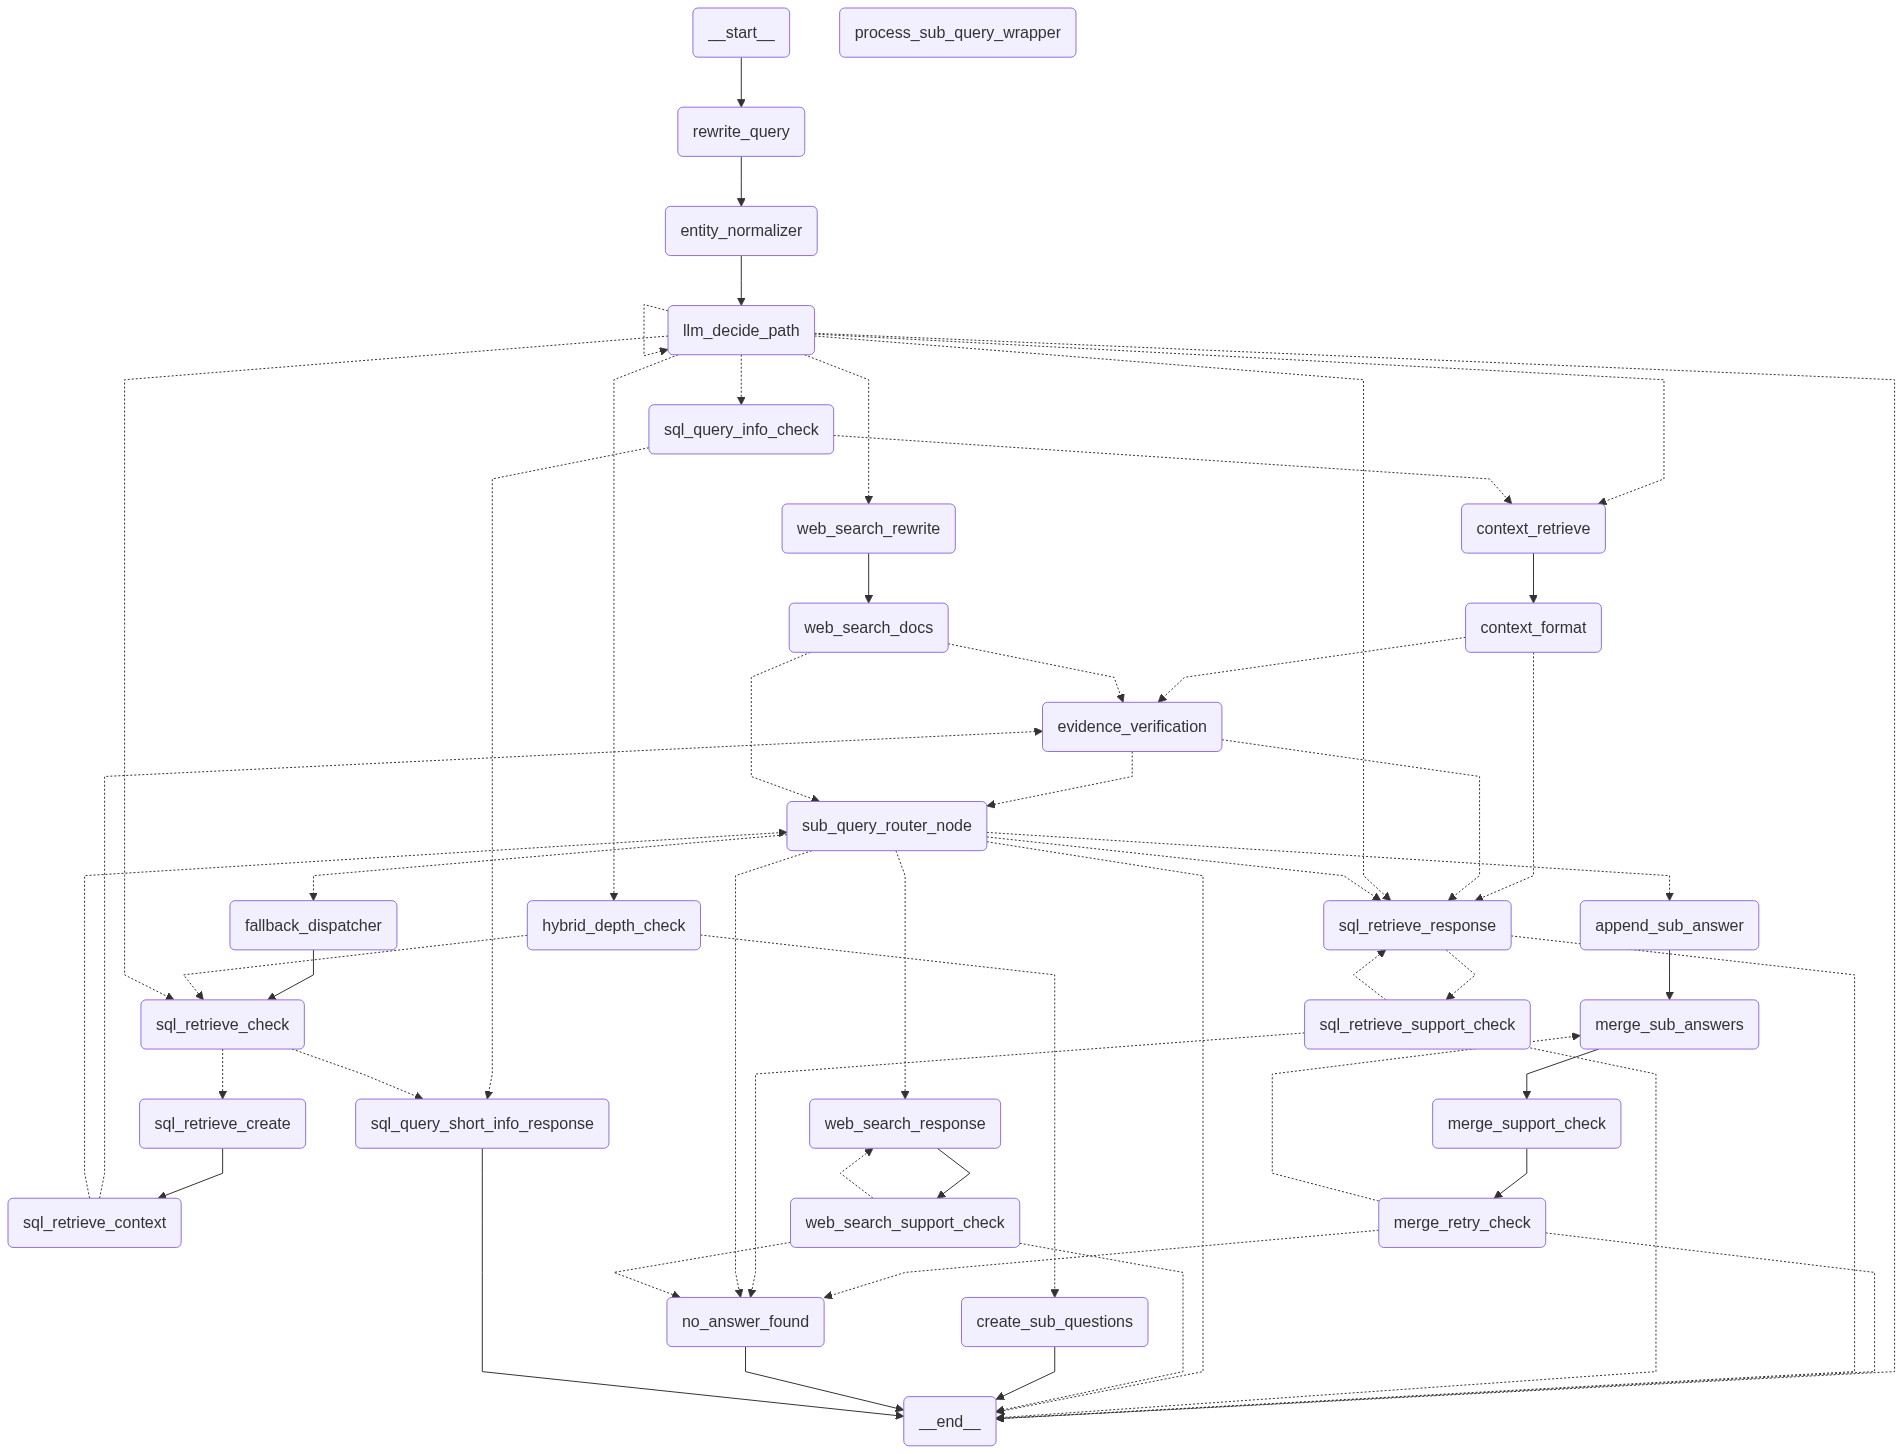

In [2]:
app=app.compile()
app